In [1]:
# ============================================
# CELL 1: LOAD DATASET
# ============================================

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("kag_risk_factors_cervical_cancer.csv")

# Initial shape
print("Initial dataset shape:", df.shape)

# Preview first few rows
df.head()


Initial dataset shape: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [2]:
# ============================================
# CELL 2: BASIC STRUCTURE CHECK
# ============================================

# Column names
print("Columns:\n", df.columns.tolist())

# Data types
print("\nData types:\n")
print(df.dtypes)

# Quick statistical overview
df.describe(include="all").T


Columns:
 ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']

Data types:

Age                                    int64
Number of sexual partners             object
First sexual intercourse              object
Num of pregnancies                    object
Smokes                                object
Smokes (years)                

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,858.0,NaN,NaN,NaN,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,858,13,2.0,272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First sexual intercourse,858,22,15.0,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Num of pregnancies,858,12,1.0,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smokes,858,3,0.0,722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smokes (years),858,31,0.0,722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smokes (packs/year),858,63,0.0,722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hormonal Contraceptives,858,3,1.0,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hormonal Contraceptives (years),858,41,0.0,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IUD,858,3,0.0,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================
# CELL 3: CHECK '?' AS MISSING VALUES
# ============================================

# Count "?" values per column
question_mark_count = (df == "?").sum().sort_values(ascending=False)

print('Columns containing "?" (hidden missing values):')
print(question_mark_count[question_mark_count > 0])


Columns containing "?" (hidden missing values):
STDs: Time since first diagnosis      787
STDs: Time since last diagnosis       787
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:HPV                              105
STDs:AIDS                             105
STDs:Hepatitis B                      105
STDs:HIV                              105
STDs                                  105
STDs:cervical condylomatosis          105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:vaginal condylomatosis           105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:condylomatosis                   105
STDs (number)                         105
Num of pregnancies                     56
Number of sexual partners              26
Smokes                      

In [4]:
# ============================================
# CELL 4: REPLACE '?' WITH NaN
# ============================================

missing_before = df.isnull().sum().sum()

# Replace '?' with NaN
df = df.replace("?", np.nan)

missing_after = df.isnull().sum().sum()

print("Missing values BEFORE replacement:", missing_before)
print("Missing values AFTER replacement :", missing_after)
print("Shape after replacement:", df.shape)


Missing values BEFORE replacement: 0
Missing values AFTER replacement : 3622
Shape after replacement: (858, 36)


In [5]:
# ============================================
# CELL 5: CONVERT OBJECT COLUMNS TO NUMERIC
# ============================================

# Identify object columns
object_cols = df.select_dtypes(include="object").columns.tolist()

print("Number of object columns before conversion:", len(object_cols))

# Convert all object columns to numeric
for col in object_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nData types after conversion:")
print(df.dtypes.value_counts())

print("Shape after conversion:", df.shape)


Number of object columns before conversion: 26

Data types after conversion:
float64    26
int64      10
Name: count, dtype: int64
Shape after conversion: (858, 36)


In [6]:
# ============================================
# CELL 6: REMOVE DUPLICATE ROWS
# ============================================

shape_before = df.shape
duplicate_rows = df.duplicated().sum()

df = df.drop_duplicates()
shape_after = df.shape

print("Duplicate rows found:", duplicate_rows)
print("Shape before removing duplicates:", shape_before)
print("Shape after removing duplicates :", shape_after)


Duplicate rows found: 23
Shape before removing duplicates: (858, 36)
Shape after removing duplicates : (835, 36)


In [7]:
# ============================================
# CELL 7: MISSING VALUE IMPUTATION
# Strategy: Median (standard for medical data)
# ============================================

missing_before = df.isnull().sum().sum()
print("Total missing BEFORE imputation:", missing_before)

# Median imputation for each column
for col in df.columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

missing_after = df.isnull().sum().sum()
print("Total missing AFTER imputation :", missing_after)

print("Shape after imputation:", df.shape)


Total missing BEFORE imputation: 3485
Total missing AFTER imputation : 0
Shape after imputation: (835, 36)


In [8]:
# ============================================
# CELL 8: FINAL DATASET SUMMARY
# ============================================

print("Final cleaned dataset shape:", df.shape)

print("\nFinal data type distribution:")
print(df.dtypes.value_counts())

# Preview cleaned data
df.head()


Final cleaned dataset shape: (835, 36)

Final data type distribution:
float64    26
int64      10
Name: count, dtype: int64


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,4.0,3.0,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,4.0,3.0,0,0,0,0,0,0,0,0


In [9]:
# Optional: Save cleaned dataset
df.to_csv("cervical_cancer_cleaned.csv", index=False)
print("Cleaned dataset saved as cervical_cancer_cleaned.csv")


Cleaned dataset saved as cervical_cancer_cleaned.csv


In [10]:
# ============================================
# CELL 9: BASIC EDA (DESCRIPTIVE ANALYSIS)
# ============================================

# Dataset shape
print("Dataset shape:", df.shape)

# Check missing values (should be zero)
print("\nTotal missing values:", df.isnull().sum().sum())

# Summary statistics for numerical features
print("\nNumerical feature summary:")
display(df.describe().T)

# Target distribution (Biopsy is recommended target)
print("\nTarget (Biopsy) distribution:")
print(df["Biopsy"].value_counts())

print("\nTarget (Biopsy) proportion:")
print(df["Biopsy"].value_counts(normalize=True))


Dataset shape: (835, 36)

Total missing values: 0

Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
Age,835.0,27.023952,8.482986,13.0,21.0,26.0,32.0,84.0
Number of sexual partners,835.0,2.535329,1.654044,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,835.0,17.020359,2.805154,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,835.0,2.283832,1.408152,0.0,1.0,2.0,3.0,11.0
Smokes,835.0,0.147305,0.354623,0.0,0.0,0.0,0.0,1.0
Smokes (years),835.0,1.234329,4.111264,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),835.0,0.458571,2.239363,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,835.0,0.694611,0.460848,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),835.0,2.080520,3.601364,0.0,0.0,0.5,3.0,30.0
IUD,835.0,0.099401,0.299379,0.0,0.0,0.0,0.0,1.0



Target (Biopsy) distribution:
Biopsy
0    781
1     54
Name: count, dtype: int64

Target (Biopsy) proportion:
Biopsy
0    0.935329
1    0.064671
Name: proportion, dtype: float64


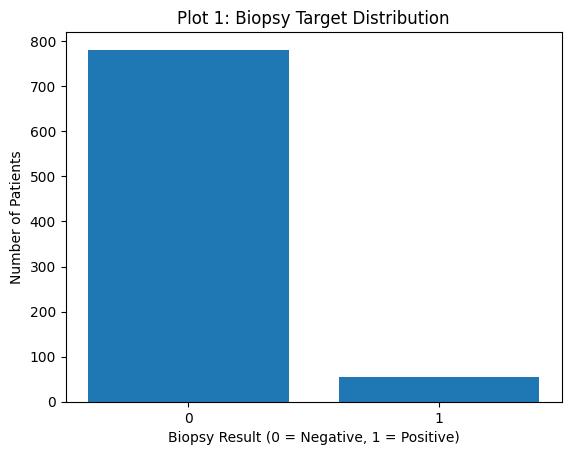

In [11]:
# ============================================
# PLOT 1: TARGET DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt

plt.figure()
counts = df["Biopsy"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Biopsy Result (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Patients")
plt.title("Plot 1: Biopsy Target Distribution")

plt.show()


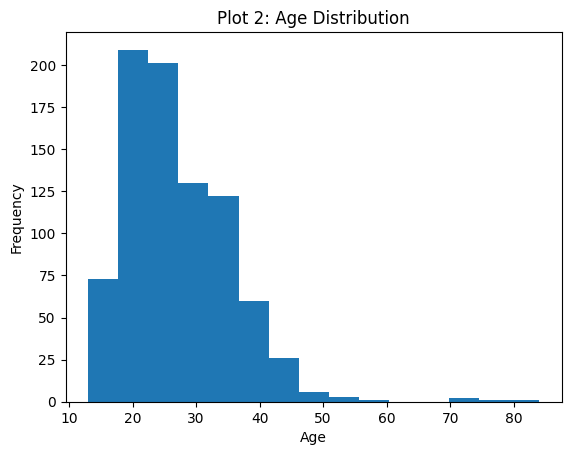

In [12]:
# ============================================
# PLOT 2: AGE DISTRIBUTION
# ============================================

plt.figure()
plt.hist(df["Age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Plot 2: Age Distribution")

plt.show()


/tmp/ipython-input-1743102113.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([age_neg, age_pos],


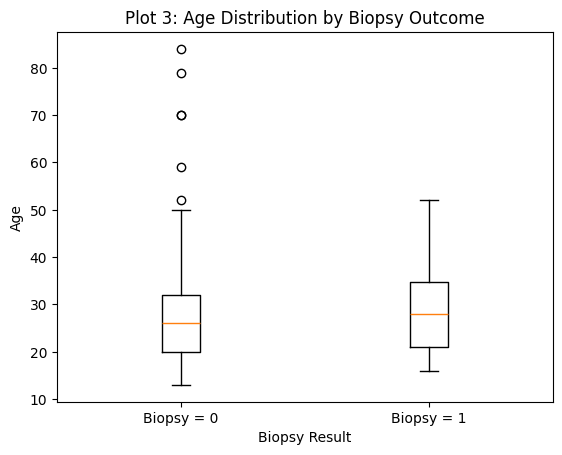

In [13]:
# ============================================
# PLOT 3: AGE vs BIOPSY (BOXPLOT)
# ============================================

plt.figure()

age_neg = df[df["Biopsy"] == 0]["Age"]
age_pos = df[df["Biopsy"] == 1]["Age"]

plt.boxplot([age_neg, age_pos],
            labels=["Biopsy = 0", "Biopsy = 1"])

plt.xlabel("Biopsy Result")
plt.ylabel("Age")
plt.title("Plot 3: Age Distribution by Biopsy Outcome")

plt.show()


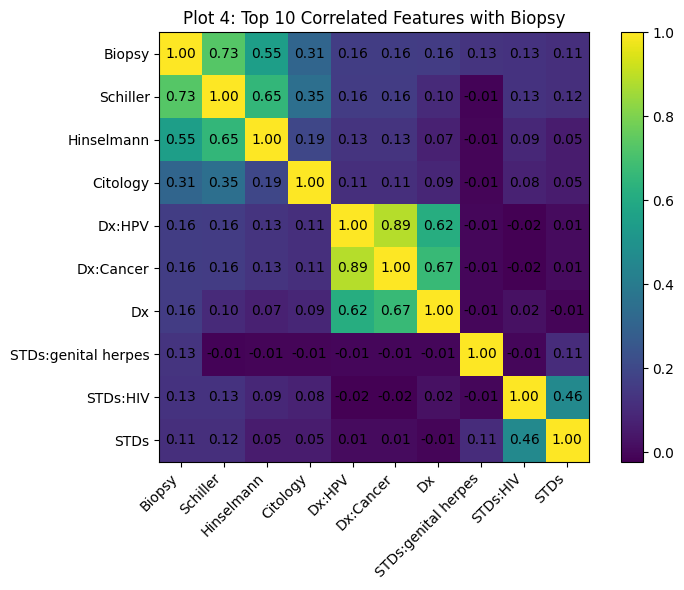

In [14]:
# ============================================
# PLOT 4: CORRELATION HEATMAP (TOP 10)
# ============================================

import numpy as np

# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Select top 10 features most correlated with Biopsy
top_corr = corr_matrix["Biopsy"].abs().sort_values(ascending=False).head(10).index
top_corr_matrix = corr_matrix.loc[top_corr, top_corr]

plt.figure(figsize=(8, 6))
plt.imshow(top_corr_matrix)
plt.colorbar()

# Annotate correlation values
for i in range(len(top_corr)):
    for j in range(len(top_corr)):
        plt.text(j, i, f"{top_corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.xticks(range(len(top_corr)), top_corr, rotation=45, ha="right")
plt.yticks(range(len(top_corr)), top_corr)

plt.title("Plot 4: Top 10 Correlated Features with Biopsy")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

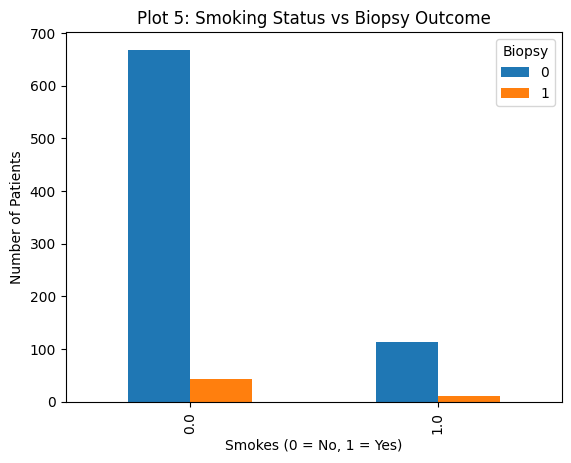

In [15]:
# ============================================
# PLOT 5: SMOKING vs BIOPSY
# ============================================

plt.figure()

smoke_biopsy = df.groupby(["Smokes", "Biopsy"]).size().unstack()

smoke_biopsy.plot(kind="bar")

plt.xlabel("Smokes (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.title("Plot 5: Smoking Status vs Biopsy Outcome")
plt.legend(title="Biopsy")

plt.show()


In [16]:
# ============================================
# CELL 10: FEATURE SELECTION (REMOVE LEAKAGE)
# ============================================

# Define target variable
target = "Biopsy"

# Columns that cause target leakage
leakage_columns = [
    "Dx:Cancer",
    "Dx:CIN",
    "Dx:HPV",
    "Dx",
    "Hinselmann",
    "Schiller",
    "Citology"
]

# Drop leakage columns
df_fs = df.drop(columns=leakage_columns)

print("Shape BEFORE feature selection:", df.shape)
print("Shape AFTER feature selection :", df_fs.shape)

print("\nRemaining columns:")
print(df_fs.columns.tolist())


Shape BEFORE feature selection: (835, 36)
Shape AFTER feature selection : (835, 29)

Remaining columns:
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Biopsy']


In [17]:
# ============================================
# CELL 11: FEATURE & TARGET SEPARATION
# ============================================

X = df_fs.drop(columns=[target])
y = df_fs[target]

print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)

print("\nTarget class distribution:")
print(y.value_counts())


Feature matrix shape (X): (835, 28)
Target vector shape (y): (835,)

Target class distribution:
Biopsy
0    781
1     54
Name: count, dtype: int64


In [18]:
# ============================================
# CELL 12: TRAIN–TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))


X_train shape: (668, 28)
X_test shape : (167, 28)
y_train shape: (668,)
y_test shape : (167,)

Training target distribution:
Biopsy
0    0.935629
1    0.064371
Name: proportion, dtype: float64


In [19]:
# ============================================
# CELL 13: STANDARD SCALER
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only (prevents data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)


Scaling completed.
Scaled X_train shape: (668, 28)
Scaled X_test shape : (167, 28)


In [20]:
# ============================================
# CELL 13: STANDARD SCALER
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only (prevents data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)


Scaling completed.
Scaled X_train shape: (668, 28)
Scaled X_test shape : (167, 28)


In [21]:
# ============================================
# CELL 14: SMOTE (CLASS BALANCING)
# ============================================

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE class distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE class distribution:")
print(pd.Series(y_train_smote).value_counts())

print("\nSMOTE-applied training shape:", X_train_smote.shape)


Before SMOTE class distribution:
Biopsy
0    625
1     43
Name: count, dtype: int64

After SMOTE class distribution:
Biopsy
0    625
1    625
Name: count, dtype: int64

SMOTE-applied training shape: (1250, 28)


In [22]:
# ============================================
# MODEL 1: RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,      # number of trees
    random_state=42
)

# Train on SMOTE-balanced training data
rf_model.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.8982035928143712

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       156
           1       0.12      0.09      0.11        11

    accuracy                           0.90       167
   macro avg       0.53      0.52      0.53       167
weighted avg       0.88      0.90      0.89       167

Random Forest Confusion Matrix:
 [[149   7]
 [ 10   1]]


In [23]:
# ============================================
# MODEL 2: ADABOOST
# ============================================

from sklearn.ensemble import AdaBoostClassifier

# Initialize AdaBoost model
ada_model = AdaBoostClassifier(
    n_estimators=200,     # number of boosting rounds
    learning_rate=0.5,    # step size
    random_state=42
)

# Train on SMOTE-balanced training data
ada_model.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_ada = ada_model.predict(X_test_scaled)

# Evaluation
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nAdaBoost Classification Report:\n", classification_report(y_test, y_pred_ada))
print("AdaBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))


AdaBoost Accuracy: 0.7904191616766467

AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88       156
           1       0.04      0.09      0.05        11

    accuracy                           0.79       167
   macro avg       0.48      0.47      0.47       167
weighted avg       0.87      0.79      0.83       167

AdaBoost Confusion Matrix:
 [[131  25]
 [ 10   1]]


In [24]:
# ============================================
# MODEL 3: KNN (K-Nearest Neighbors)
# ============================================

from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5,       # number of neighbors
    metric="minkowski"   # default distance metric (Euclidean)
)

# Train on SMOTE-balanced training data
knn_model.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.7425149700598802

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85       156
           1       0.06      0.18      0.09        11

    accuracy                           0.74       167
   macro avg       0.49      0.48      0.47       167
weighted avg       0.87      0.74      0.80       167

KNN Confusion Matrix:
 [[122  34]
 [  9   2]]


In [25]:
# ============================================
# MODEL COMPARISON TABLE
# ============================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

# Random Forest metrics
results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
])

# AdaBoost metrics
results.append([
    "AdaBoost",
    accuracy_score(y_test, y_pred_ada),
    precision_score(y_test, y_pred_ada),
    recall_score(y_test, y_pred_ada),
    f1_score(y_test, y_pred_ada)
])

# KNN metrics
results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn)
])

# Create a DataFrame for readability
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.898204,0.125000,0.090909,0.105263
1,AdaBoost,0.790419,0.038462,0.090909,0.054054
2,KNN,0.742515,0.055556,0.181818,0.085106


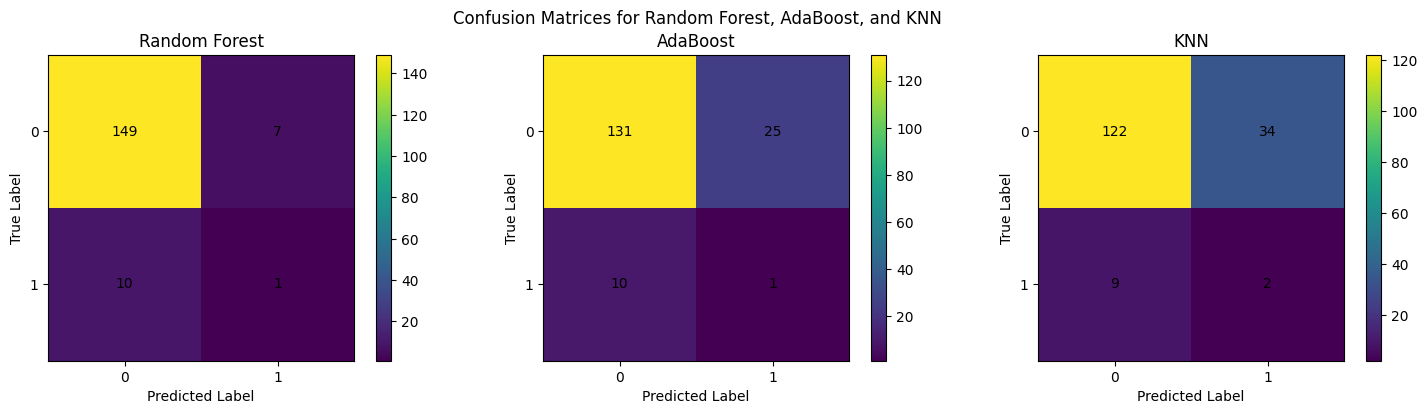

In [26]:
# ============================================
# CONFUSION MATRIX PLOTS
# ============================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

models = {
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "KNN": knn_model
}

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):

    # Predict class labels
    y_pred = model.predict(X_test_scaled)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.subplot(1, 3, i)
    plt.imshow(cm)
    plt.title(name)
    plt.colorbar()

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    # Annotate cell values
    for r in range(2):
        for c in range(2):
            plt.text(c, r, cm[r, c], ha="center", va="center")

plt.suptitle("Confusion Matrices for Random Forest, AdaBoost, and KNN")
plt.tight_layout()
plt.show()


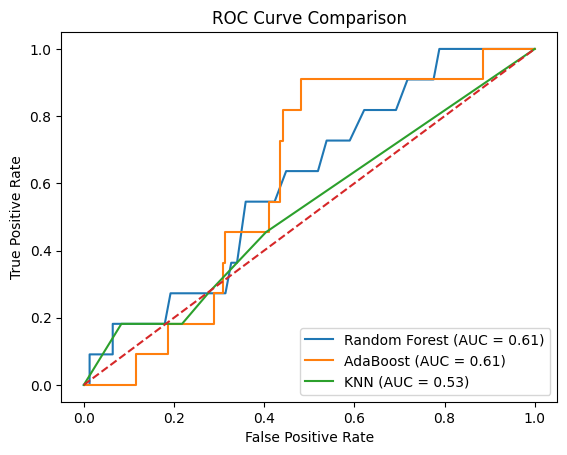

In [27]:
# ============================================
# ROC CURVE COMPARISON
# ============================================

from sklearn.metrics import roc_curve, auc

plt.figure()

for name, model in models.items():

    # Get probability scores for class = 1
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
